# Lab 2 - Atlas & Statistical shape analysis
This lab is designed to help you construct an atlas. The code and this lab will rely on multimorph.

Be sure to select the GPU in Colab for training (Runtime > Change runtime type > T4 GPU (or any other GPU available).

References:

*  Abulnaga et al., MultiMorph: On-demand Atlas Construction, CPVR 2025 : https://arxiv.org/abs/2504.00247
*   https://github.com/mabulnaga/multimorph



### Evaluation

Documents to submit :
* This notebook with your code and comments (8 points).
* A report (pdf format) presenting what you did, the statistical shape analysis you did, etc. (12 points). Maximum 3 pages.

Only one student per group needs to submit.

**Deadline** : March 10, 2026

# Atlas

### Model used

We'll be using multimorph to create an atlas.

In [2]:
!git clone https://github.com/mabulnaga/multimorph.git
%cd multimorph/src

fatal : le chemin de destination 'multimorph' existe déjà et n'est pas un répertoire vide.
/store/home/boadem/Work/School/multimorph/src


### Load Libraries

In [3]:
!pip install neurite
!pip install monai --no-deps
#!pip install git+https://github.com/adalca/neurite.git --force-reinstall --no-deps
#!pip install pystrum

In [4]:
import pathlib
import os

import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from tqdm.notebook import trange, tqdm

os.environ['NEURITE_BACKEND'] = 'pytorch'
os.environ['VXM_BACKEND'] = 'pytorch'
import neurite as ne

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")


## Dataset
The dataset is, once again, Neurite OASIS (MRI brain scans).

In [5]:
!mkdir -p oasisdata
!wget -q https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data/neurite-oasis.2d.v1.0.tar
!tar xf neurite-oasis.2d.v1.0.tar -C oasisdata/
!rm neurite-oasis.2d.v1.0.tar

### Load the Dataset

In [6]:
oasis_data_path ='oasisdata'

files = [f/'slice_norm.nii.gz' for f in pathlib.Path(oasis_data_path).iterdir() if f.is_dir()]
slices = [torch.from_numpy(nib.load(f).get_fdata())[..., 0] for f in files]
oasis_data = torch.stack(slices, dim=0).float().to(device) # put all data on cuda.

# get the segmentations
seg_files = [f/'slice_seg4.nii.gz' for f in pathlib.Path(oasis_data_path).iterdir() if f.is_dir()]
seg_slices = [torch.from_numpy(nib.load(f).get_fdata())[...,0] for f in seg_files]
oasis_data_segmentation = torch.stack(seg_slices,dim=0).float().to(device)


oasis_data = oasis_data.transpose(2, 1)
oasis_data_segmentation = oasis_data_segmentation.transpose(2,1).unsqueeze(1)


### Prepare the data


In [7]:
from dataloader import GroupDataLoader, SubGroupLoader
from torch.utils.data import DataLoader

# number of images to sample at each training iteration
n_inputs_range = [2,12]


train_pct = 0.9
N_data = len(oasis_data)
N_train = int(N_data * train_pct)
N_test = N_data - N_train
range_data = np.arange(0,N_data)
train_idx = np.random.choice(range_data, N_train, replace=False)
test_idx =np.setdiff1d(range_data, train_idx)

# split the image and segmentations into the appropriate data split
oasis_data_train = oasis_data[train_idx,:]
oasis_data_test = oasis_data[test_idx,:]
oasis_data_segmentation_train = oasis_data_segmentation[train_idx,:]
oasis_data_segmentation_test = oasis_data_segmentation[test_idx,:]

# create data loaders for train and test. The GroupDataLoader will randomly sample n_input_ranges image at each iteration.
# for the test data loader, we load the entire test set.

dataset_oasis_train = GroupDataLoader(data=oasis_data_train,labels=np.zeros(N_train), class_labels=[0],
                                      segmentations=oasis_data_segmentation_train, n_inputs_range=n_inputs_range,transform=None)
dataloader_oasis_train = DataLoader(dataset_oasis_train,batch_size=1,shuffle=True)

dataset_oasis_test = SubGroupLoader(data=[oasis_data_test],labels=None, # labels=[np.zeros(N_test)],
                                     segmentations=[oasis_data_segmentation_test], transform=None)
dataloader_oasis_test = DataLoader(dataset_oasis_test, batch_size=1, shuffle=False)



#### Visualize a few samples from the dataloader

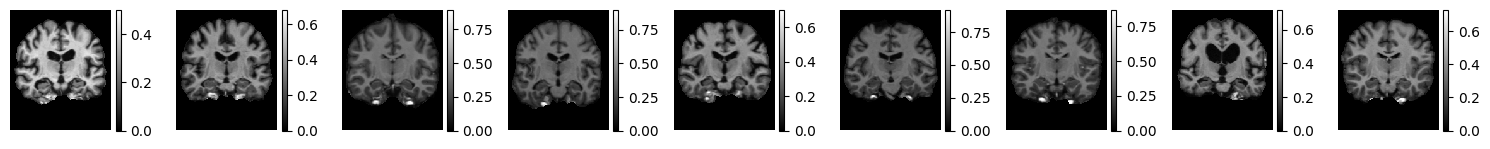

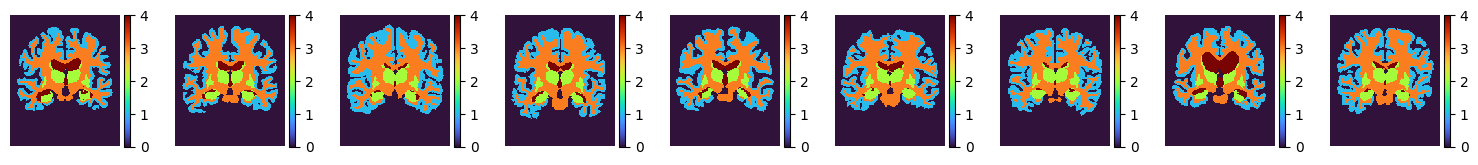

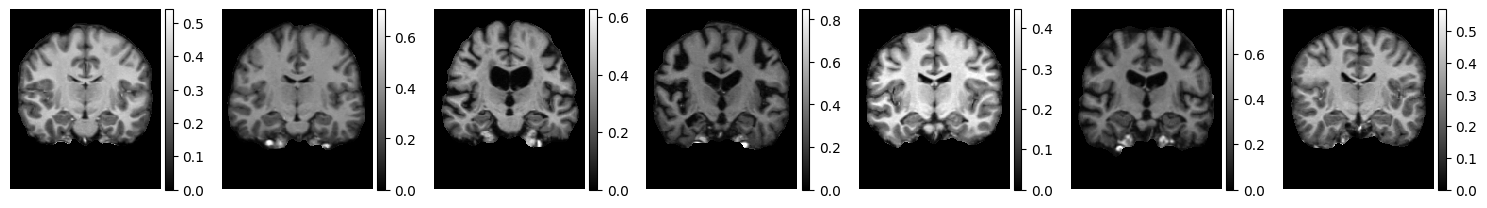

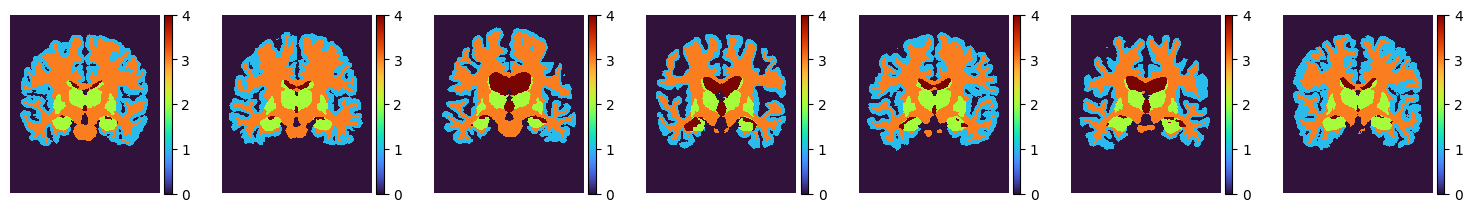

In [8]:
# grab two sets of samples from the training dataloader and visualize.
for i in range(0,2):
    sample = next(iter(dataloader_oasis_train))
    images = sample['image']
    segmentations = sample['segmentation']
    # undo one-hot encoding
    segmentations = torch.argmax(segmentations, dim=2, keepdim=True)
    # plot images
    slices = [f for f in images[0, :, 0, ...].cpu().detach().numpy()]
    ne.py.plot.slices(slices,do_colorbars=True)
    # plot segmentations
    slices_seg = [f for f in segmentations[0, :, 0, ...].cpu().detach().numpy()]
    ne.py.plot.slices(slices_seg,do_colorbars=True, cmaps=['turbo']*len(slices_seg))

## Setup the Model and Losses

In [9]:
import models as models
import layers as layers
import losses as losses
import torch.optim as optim



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/boadem/miniconda3/envs/monai_env/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/boadem/miniconda3/envs/monai_env/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/boadem/miniconda3/envs/monai_env/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in st

AttributeError: _ARRAY_API not found

2026-03-07 12:16:49.756881: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 12:16:51.193528: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 12:16:58.859298: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 12:16:58.

AttributeError: _ARRAY_API not found

#### get the image size to set up the Spatial Transformer

In [10]:
oasis_img_size = list(map(int, list(oasis_data.shape[1:])))
print(oasis_img_size)

[192, 160]


### setup the loss functions

In [11]:
img_size = torch.Size(oasis_img_size)

# image and regularization loss
criterion = losses.local_NCC_2d(volshape=img_size, lbd=1)
#criterion = losses.MinVarAndGrad2d(volshape=img_size, lbd=0.1)

# segmentation loss
seg_loss = losses.DiceWarpLoss2d(img_size)
lambda_seg = 0.5

mmnet = models.GroupNet(in_channels=1, out_channels=2, img_size=img_size, do_diffeomorphism=True).to(device)

optimizer = optim.Adam(mmnet.parameters(), lr=0.001)


/home/boadem/miniconda3/envs/monai_env/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538437738/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Train

In [12]:
# nb_epochs = 100
# batch_size = 1
# data_loader = dataloader_oasis_train
# mmnet = mmnet.to(device)

# pbar = trange(nb_epochs)
# loss_hist = np.zeros(nb_epochs)

# for i in pbar:
#     total_running_loss = list()
#     mmnet.train()
#     for sample in data_loader:
#         images = sample['image'].to(device)
#         segmentations = sample['segmentation'].to(device)

#         # zero the parameter gradients
#         optimizer.zero_grad()
#         # predict the warp fields
#         predw = mmnet(images)
#         # compute the loss
#         loss = criterion(images, predw)
#         loss_seg = seg_loss(segmentations,predw)
#         loss = loss + lambda_seg * loss_seg
#         total_running_loss.append(loss.item())
#         #optimize
#         loss.backward()
#         optimizer.step()

#     # print stats
#     m = np.mean(total_running_loss)
#     pbar.set_description(f'{m:.5f}')
#     loss_hist[i] = m

# print('Finished Training')

Don't forget to save your model. Especially if you use colab. Otherwise it'll be deleted after you close your browser.

In [13]:
# save your model
# torch.save(mmnet.state_dict(), '/home/boadem/Work/School/mmnet_oasis.pth')

In [14]:
# load the model (previously saved)
saved_model = torch.load('/home/boadem/Work/School/mmnet_oasis.pth')

/tmp/ipykernel_358263/1750743970.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_model = torch.load('/home/boadem/Work/School/mmnet_oasis.pth')


#### Visualize the training loss

In [15]:
# # lets quickly see the training curve
# plt.figure(figsize=(15, 7))
# plt.subplot(1,2,1)
# plt.plot(loss_hist)
# plt.ylabel('Loss')
# plt.xlabel('Epochs')
# plt.title('Training Loss')
# plt.grid()


## Visualize the warps and atlas on samples from the train set

### setup a few plotting and warping functions

In [16]:
from utils import warp_seg, warp_image, warp_grid, setup_grid_tensor, plot_row_slices

### load a sample and plot the images and segmentations after warping

Original Images


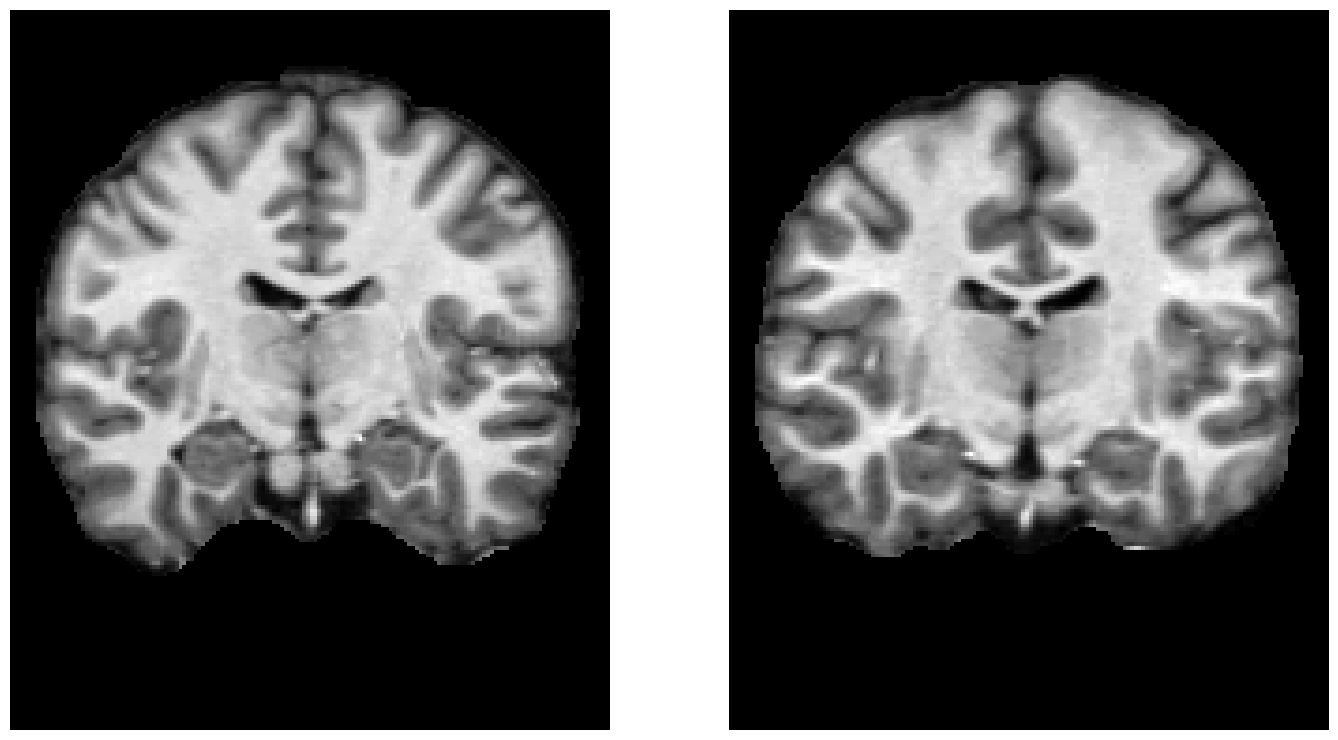

Warped Images


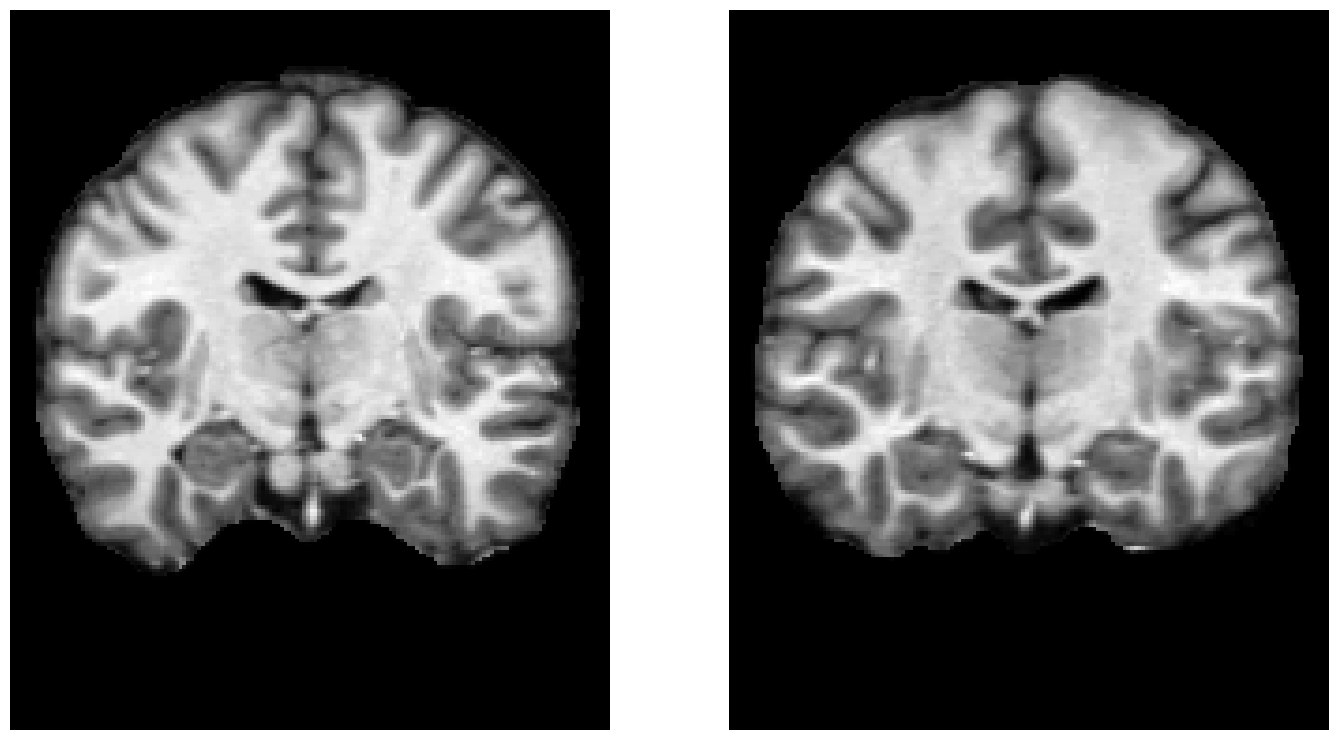

Original Segmentations


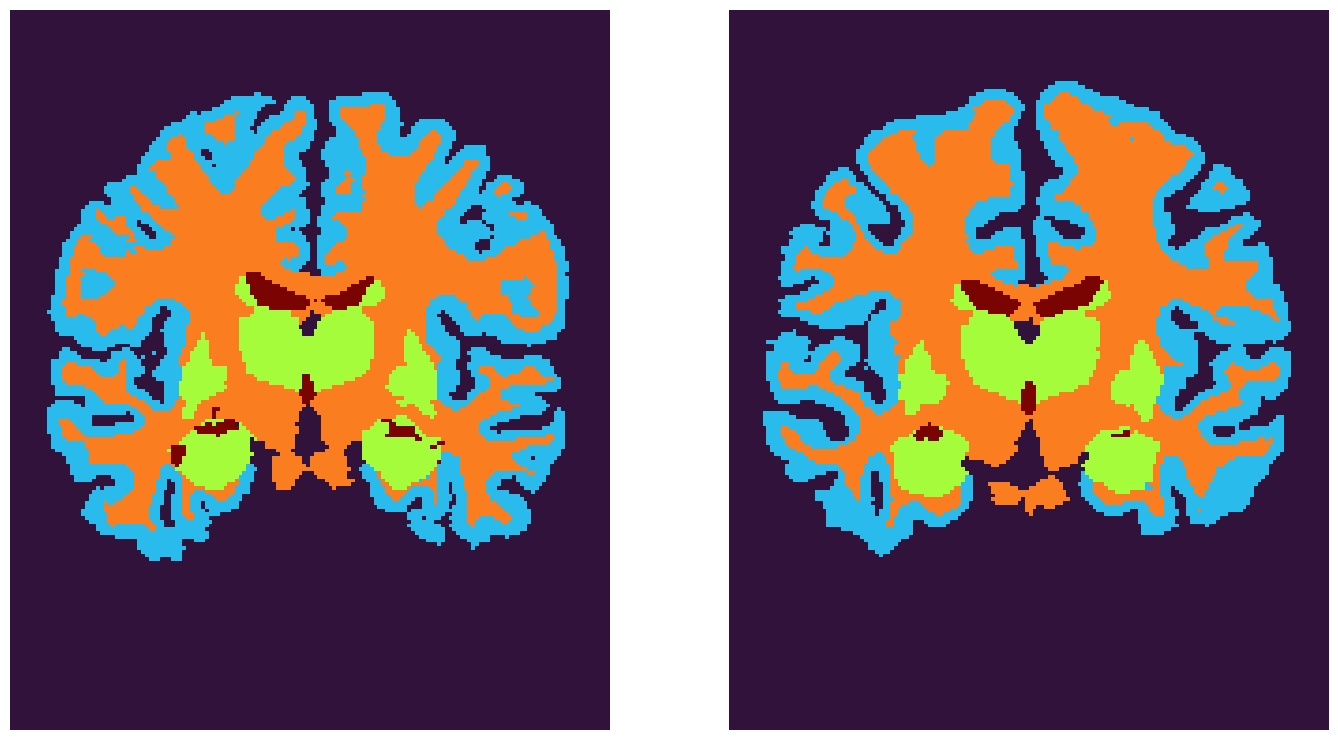

Warped Segmentations


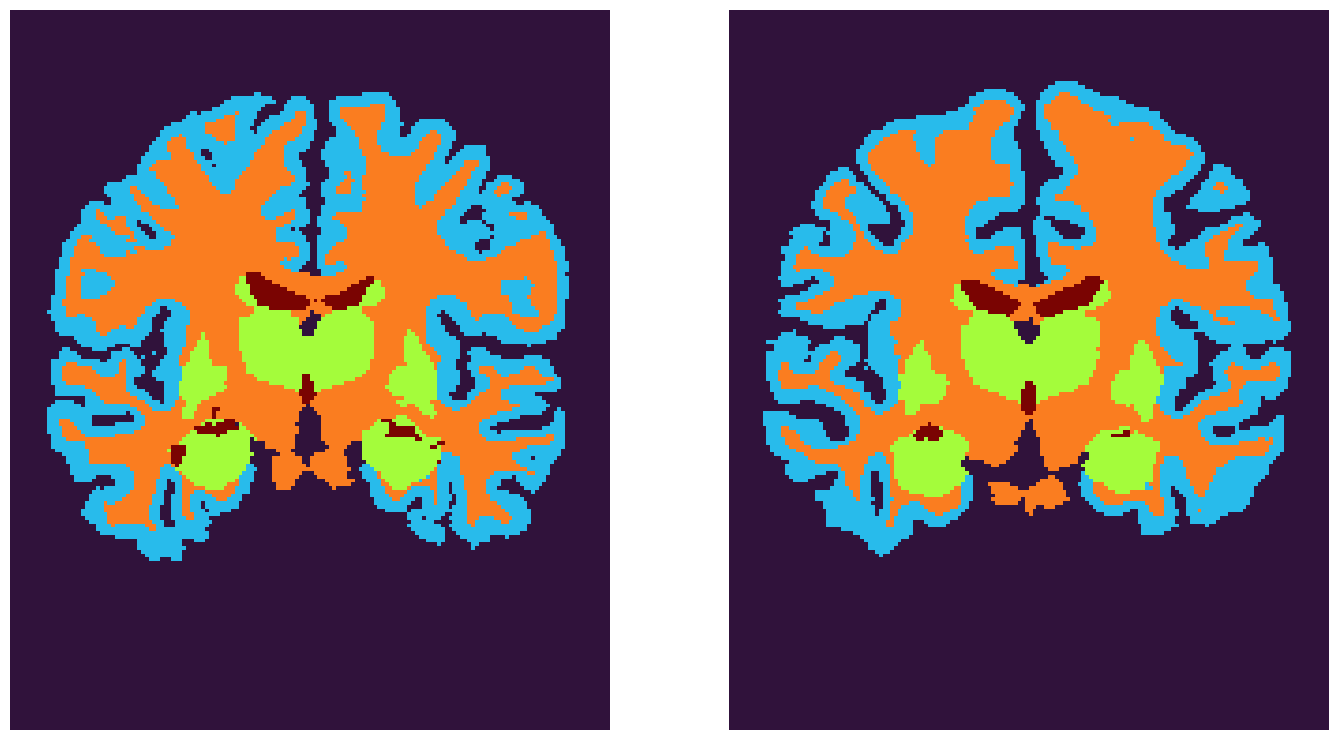

Warped Grid


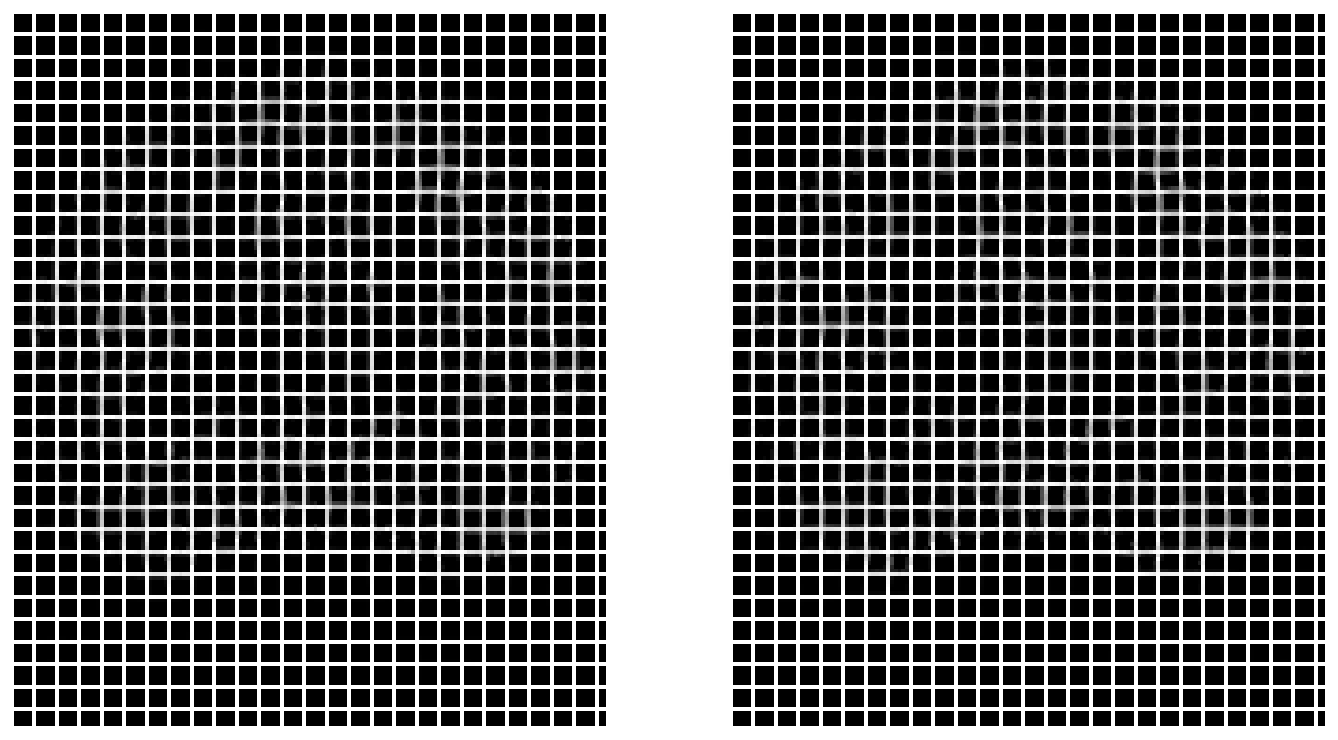

(<Figure size 1500x750 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

In [17]:
img_size = oasis_img_size
dataset = dataset_oasis_train
warp_dim = img_size

# set up the train data loader
mmnet.to(device)
gen =  iter(DataLoader(dataset,batch_size=1,shuffle=False))

# grab a sample from the data loader
sample = next(gen)
images = sample['image'].to(device)
segs = sample['segmentation'].to(device)
N_images = np.shape(images)[1]

# warp and plot original, warped images
warped, predicted_warp = warp_image(images,mmnet,img_size)
warped_seg = warp_seg(segs, predicted_warp, img_size=img_size)

# plot the original and warped images
print('Original Images')
plot_row_slices(images, do_colorbars=False)
print('Warped Images')
plot_row_slices(warped, do_colorbars=False)

# plot the original and warped segmentations
print('Original Segmentations')
plot_row_slices(torch.round(torch.argmax(segs, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)
print('Warped Segmentations')
plot_row_slices(torch.round(torch.argmax(warped_seg, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)

# Create a grid and plot the warped grid
grids = setup_grid_tensor(N_slices=N_images,spacing=5, img_size=img_size).to(device)
warped_grid = warp_grid(grids, predicted_warp, warp_dim=img_size)
print('Warped Grid')
plot_row_slices(warped_grid, do_colorbars=False)

Original Images


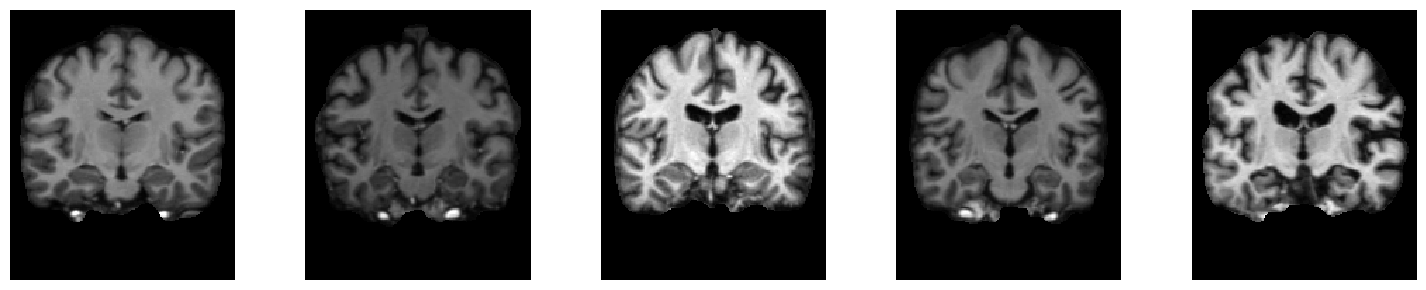

Warped Images


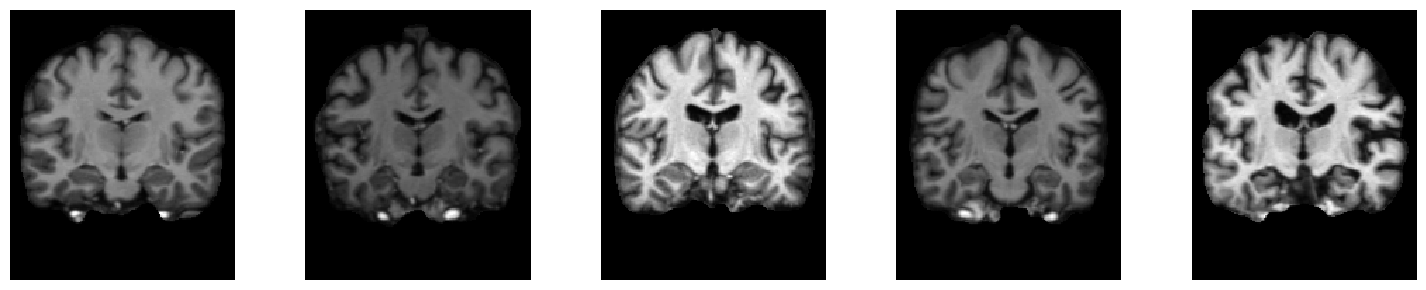

Original Segmentations


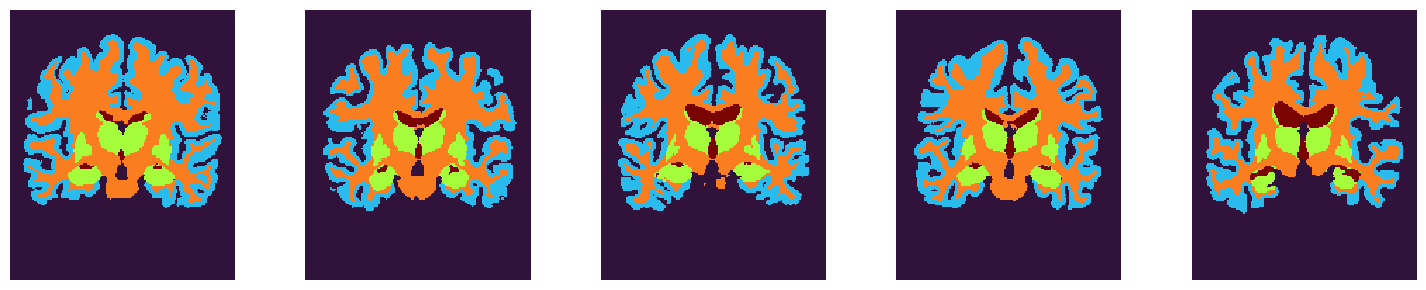

Warped Segmentations


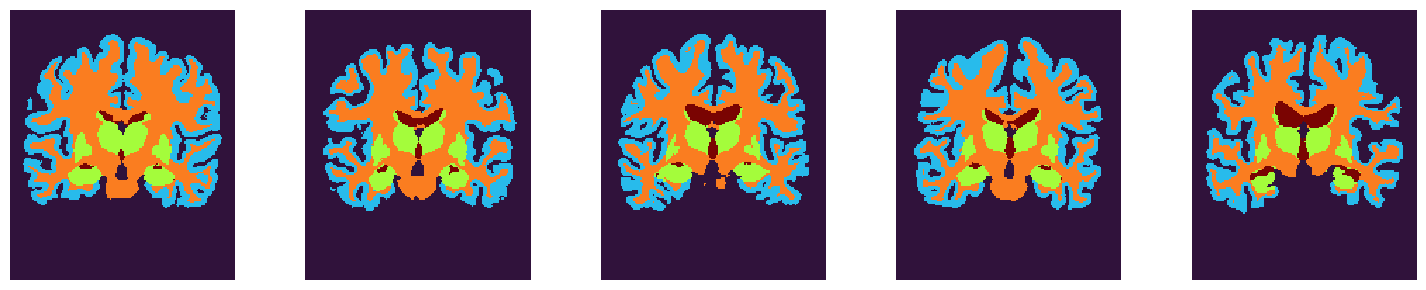

Warped Grid


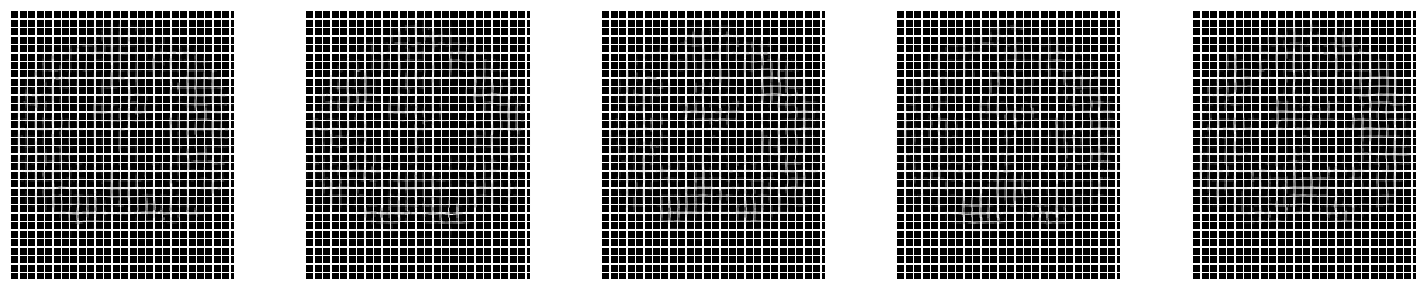

(<Figure size 1500x300 with 5 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

In [18]:
img_size = oasis_img_size
dataset = dataset_oasis_train
warp_dim = img_size

# set up the train data loader
mmnet.to(device)
gen =  iter(DataLoader(dataset,batch_size=1,shuffle=False))

# grab a sample from the data loader
sample = next(gen)
images = sample['image'].to(device)
segs = sample['segmentation'].to(device)
N_images = np.shape(images)[1]

# warp and plot original, warped images
warped, predicted_warp = warp_image(images,mmnet,img_size)
warped_seg = warp_seg(segs, predicted_warp, img_size=img_size)

# plot the original and warped images
print('Original Images')
plot_row_slices(images, do_colorbars=False)
print('Warped Images')
plot_row_slices(warped, do_colorbars=False)

# plot the original and warped segmentations
print('Original Segmentations')
plot_row_slices(torch.round(torch.argmax(segs, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)
print('Warped Segmentations')
plot_row_slices(torch.round(torch.argmax(warped_seg, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)

# Create a grid and plot the warped grid
grids = setup_grid_tensor(N_slices=N_images,spacing=5, img_size=img_size).to(device)
warped_grid = warp_grid(grids, predicted_warp, warp_dim=img_size)
print('Warped Grid')
plot_row_slices(warped_grid, do_colorbars=False)

### visualize the resultant atlases, and compare to constructing an atlas by taking the mean

In [19]:
# TODO
# Load the saved model weights into a new instance of the model
mmnet = models.GroupNet(in_channels=1, out_channels=2, img_size=img_size, do_diffeomorphism=True).to(device)
mmnet.load_state_dict(saved_model)




<All keys matched successfully>

## Construct an Atlas on the Entire Test Set

In [20]:
import time

all_dvfs = []

mmnet = mmnet.to('cpu')
mmnet.eval()
warp_layer = layers.group.Warp2d(img_size)
for sample in dataloader_oasis_test:
    st = time.time()
    images = sample['image'].to('cpu')
    segmentations = sample['segmentation'].to('cpu')
    # predict the warp fields
    predw = mmnet(images)
    all_dvfs.append(predw.cpu().detach().numpy())
    # warp and plot original, warped images
    warped = warp_layer(images, predw)
    # warped_seg = warp_layer(segmentations, predw)
    warped_seg = warp_seg(segmentations, predw, img_size=img_size)

# construct the atlases
atlas = torch.mean(warped, dim=1, keepdims=True)
atlas_segmentation = torch.round(torch.argmax(torch.mean(warped_seg, dim=1, keepdims=True), dim=2, keepdim=True))

et = time.time()
print(f'Atlas Construction took {et-st:.3f} seconds for {images.shape[1]} images')


naive_atlas = torch.mean(images, dim=1, keepdims=True)
naive_atlas_segmentation = torch.round(torch.argmax(torch.mean(segmentations, dim=1, keepdims=True), dim=2, keepdim=True))


Atlas Construction took 3.896 seconds for 42 images


#### plot the constructed atlases

Text(0.5, 1.0, 'Naive Atlas Segmentation')

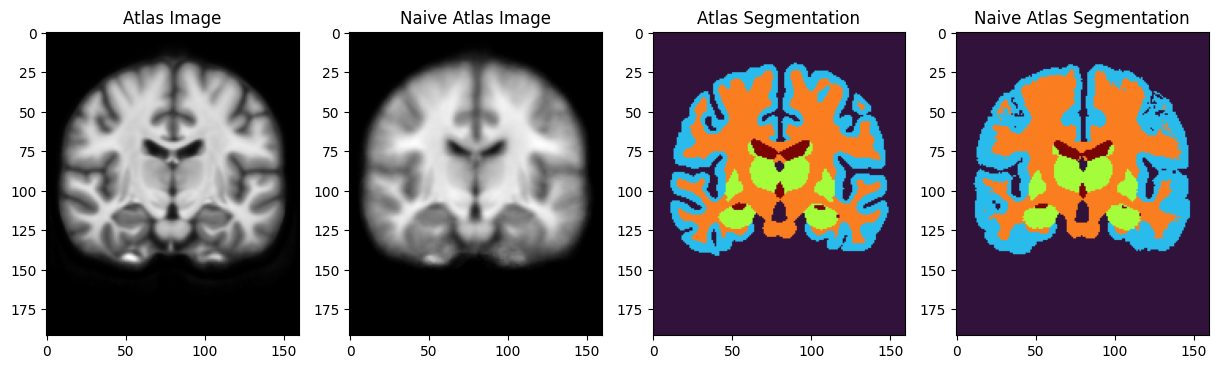

In [21]:
# TODO
atlas_img = atlas.squeeze().squeeze().cpu().detach().numpy()
naive_atlas_img = naive_atlas.squeeze().squeeze().cpu().detach().numpy()

plt.figure(figsize=(15, 7))

plt.subplot(141)
plt.imshow(atlas_img, cmap='gray')
plt.title('Atlas Image')

plt.subplot(142)
plt.imshow(naive_atlas_img, cmap='gray')
plt.title('Naive Atlas Image')

plt.subplot(143)
plt.imshow(atlas_segmentation.squeeze().squeeze().cpu().detach().numpy(), cmap='turbo')
plt.title('Atlas Segmentation')

plt.subplot(144)
plt.imshow(naive_atlas_segmentation.squeeze().squeeze().cpu().detach().numpy(), cmap='turbo')
plt.title('Naive Atlas Segmentation')

### save the atlases (don't forget to download them if you use google colab)

In [22]:
# atlas_path = '/home/boadem/Work/School/oasis_atlas_2d.nii.gz'
# atlas_segmentation_path = '/home/boadem/Work/School/oasis_atlas_segmentation_2d.nii.gz'
# nib.save(nib.Nifti1Image(atlas[0, 0, 0, ...].cpu().detach().numpy(), np.eye(4)), atlas_path)
# nib.save(nib.Nifti1Image(atlas_segmentation[0, 0, 0, ...].float().cpu().detach().numpy(), np.eye(4)), atlas_segmentation_path)


# Statistical Shape analysis

Related to course 6 : Statistical Shape Analysis.

Present other statistical shape analyses that you consider relevant. Please include plots of your results.

You can use velocity fields (available in the code : https://github.com/mabulnaga/multimorph/blob/main/src/models.py) and compute PCA, Standard deviation, etc. Feel free to go wild!

In [23]:
# TODO
#Tensor based morphometry 
def jacobian_determinant(flow):
    """
    Computes the Jacobian determinant of a 2D registration flow.
    flow shape: [Batch, 2, H, W]
    """
    # Compute gradients of the flow field
    dy = flow[:, 1:, 1:, :] - flow[:, 1:, :-1, :]
    dx = flow[:, :1, :, 1:] - flow[:, :1, :, :-1]

    
    
    # Extract u and v components
    u = flow[:, 0, :, :]
    v = flow[:, 1, :, :]

    # Calculate partial derivatives
    du_dx, du_dy = torch.gradient(u, spacing=(1, 1), dim=(-2, -1))
    dv_dx, dv_dy = torch.gradient(v, spacing=(1, 1), dim=(-2, -1))

    det = (du_dx + 1) * (dv_dy + 1) - (du_dy * dv_dx)
    
    return det

def compute_jacobian(flow):
    """
    Computes the Jacobian matrix of a 2D registration flow.
    flow shape: [Batch, 2, H, W]
    """
    # Extract u and v components
    u = flow[:, 0, :, :]
    v = flow[:, 1, :, :]

    # Calculate partial derivatives
    du_dx, du_dy = torch.gradient(u, spacing=(1, 1), dim=(-2, -1))
    dv_dx, dv_dy = torch.gradient(v, spacing=(1, 1), dim=(-2, -1))

    # Construct the Jacobian matrix
    jacobian = torch.stack([
        torch.stack([du_dx + 1, du_dy], dim=-1),
        torch.stack([dv_dx, dv_dy + 1], dim=-1)
    ], dim=-3)

    return jacobian



torch.Size([192, 160])


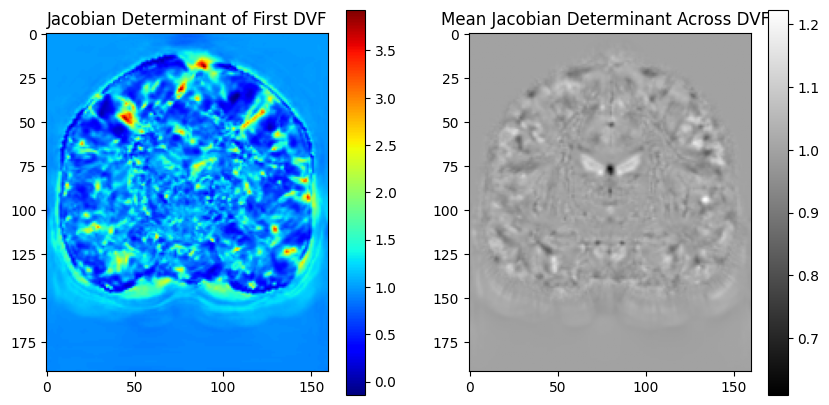

In [24]:
post_dvfs = all_dvfs[0].squeeze(0)


jac_dets = jacobian_determinant(torch.tensor(post_dvfs))

jac_det_0 = jac_dets[0, ...]

mean_jac_det = torch.mean(jac_dets, dim=0)

print(mean_jac_det.shape)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(jac_det_0, cmap='jet')
plt.title('Jacobian Determinant of First DVF')
plt.colorbar()

plt.subplot(122)
plt.imshow(mean_jac_det, cmap='gray')
plt.title('Mean Jacobian Determinant Across DVFs')
plt.colorbar()


Deformation fields shape: (42, 2, 192, 160)
Brain-mask voxels: 17071/30720


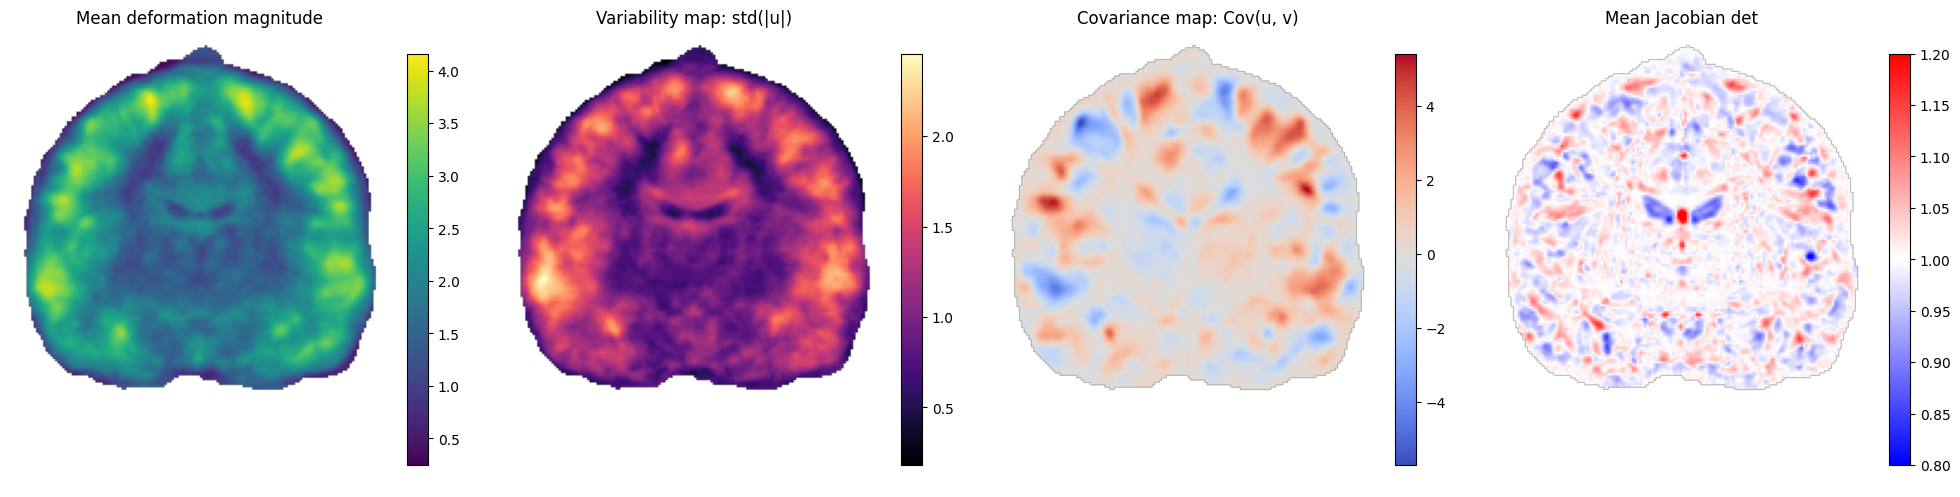

In [25]:
# Cell A: Deformation magnitude + variability maps + covariance map + mean Jacobian det
import numpy as np
import torch
import matplotlib.pyplot as plt


from scipy.ndimage import binary_fill_holes, binary_erosion, binary_dilation

# -------------------- 1) Load deformation fields --------------------
if 'post_dvfs' in globals() and post_dvfs is not None:
    flow_np = post_dvfs.detach().cpu().numpy() if torch.is_tensor(post_dvfs) else np.asarray(post_dvfs)
elif 'all_dvfs' in globals() and len(all_dvfs) > 0:
    cand = all_dvfs[0]
    flow_np = cand.detach().cpu().numpy() if torch.is_tensor(cand) else np.asarray(cand)
    if flow_np.ndim == 5 and flow_np.shape[0] == 1:
        flow_np = np.squeeze(flow_np, axis=0)


N, C, H, W = flow_np.shape
print(f'Deformation fields shape: {(N, C, H, W)}')

# -------------------- 2) Build brain mask --------------------
brain_ref = None
if 'oasis_data_test' in globals():
    ref = oasis_data_test
    ref_np = ref.detach().cpu().numpy() if torch.is_tensor(ref) else np.asarray(ref)
    if ref_np.ndim == 3:
        brain_ref = ref_np.mean(axis=0)
    else:
        brain_ref = np.squeeze(ref_np).mean(axis=0)
elif 'atlas' in globals():
    ref = atlas
    ref_np = ref.detach().cpu().numpy() if torch.is_tensor(ref) else np.asarray(ref)
    while ref_np.ndim > 2:
        ref_np = np.squeeze(ref_np, axis=0)
    brain_ref = ref_np

if brain_ref is None:
    brain_mask = np.ones((H, W), dtype=bool)
else:
    brain_ref = np.asarray(brain_ref, dtype=np.float32)
    if brain_ref.shape != (H, W):
        tmp = np.zeros((H, W), dtype=np.float32)
        mh = min(H, brain_ref.shape[0])
        mw = min(W, brain_ref.shape[1])
        tmp[:mh, :mw] = brain_ref[:mh, :mw]
        brain_ref = tmp

    thr = np.percentile(brain_ref, 35)
    brain_mask = brain_ref > thr
    brain_mask = binary_fill_holes(brain_mask)
    brain_mask = binary_dilation(brain_mask, structure=np.ones((3, 3), dtype=bool), iterations=1)
    brain_mask = binary_erosion(brain_mask, structure=np.ones((3, 3), dtype=bool), iterations=3)

margin = 6
inside = np.zeros((H, W), dtype=bool)
inside[margin:H-margin, margin:W-margin] = True
brain_mask = brain_mask & inside
print(f'Brain-mask voxels: {int(brain_mask.sum())}/{H*W}')

# -------------------- 3) Deformation/Jacobian summaries --------------------
u = flow_np[:, 0, :, :]
v = flow_np[:, 1, :, :]
mag = np.sqrt(u**2 + v**2)

du_dy, du_dx = np.gradient(u, axis=(1, 2))
dv_dy, dv_dx = np.gradient(v, axis=(1, 2))

J11 = 1.0 + du_dx
J12 = du_dy
J21 = dv_dx
J22 = 1.0 + dv_dy
jacdet = J11 * J22 - J12 * J21

mean_mag = mag.mean(axis=0)
std_mag = mag.std(axis=0, ddof=1)
cov_uv = ((u - u.mean(axis=0)[None, :, :]) * (v - v.mean(axis=0)[None, :, :])).sum(axis=0) / max(N - 1, 1)
mean_jacdet = jacdet.mean(axis=0)


fig, ax = plt.subplots(1, 4, figsize=(20, 5))

im = ax[0].imshow(np.where(brain_mask, mean_mag, np.nan), cmap='viridis')
ax[0].set_title('Mean deformation magnitude')
ax[0].axis('off'); plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

im = ax[1].imshow(np.where(brain_mask, std_mag, np.nan), cmap='magma')
ax[1].set_title('Variability map: std(|u|)')
ax[1].axis('off'); plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)

im = ax[2].imshow(np.where(brain_mask, cov_uv, np.nan), cmap='coolwarm')
ax[2].set_title('Covariance map: Cov(u, v)')
ax[2].axis('off'); plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

im = ax[3].imshow(np.where(brain_mask, mean_jacdet, np.nan), cmap='bwr', vmin=0.8, vmax=1.2)
ax[3].set_title('Mean Jacobian det')
ax[3].axis('off'); plt.colorbar(im, ax=ax[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Save base outputs for next cell (PCA/modes)
deformation_base = {
    'flow_np': flow_np,
    'brain_mask': brain_mask,
    'mean_mag': mean_mag,
    'std_mag': std_mag,
    'cov_uv': cov_uv,
    'jacdet': jacdet,
    'mean_jacdet': mean_jacdet,
}


### Quick distinction: PCA vs PGA

- **This cell (PCA)** treats each deformation field as a vector in a flat Euclidean space, then applies standard PCA (SVD). The mean is the arithmetic mean of fields, and mode variation is linear: $\mu \pm 2\sigma v_k$.
- **PGA (below)** is the manifold version: it computes a Fréchet mean on transformations, uses log-maps to tangent vectors, does PCA in that tangent space, then maps back with exp-maps.
- **Interpretation**: PCA is simpler and fast; PGA is more geometrically faithful when deformations are large/nonlinear.

Explained variance ratio (first modes):
  Mode 1: 25.77%
  Mode 2: 11.85%
  Mode 3: 7.52%
  Cumulative (3 modes): 45.15%


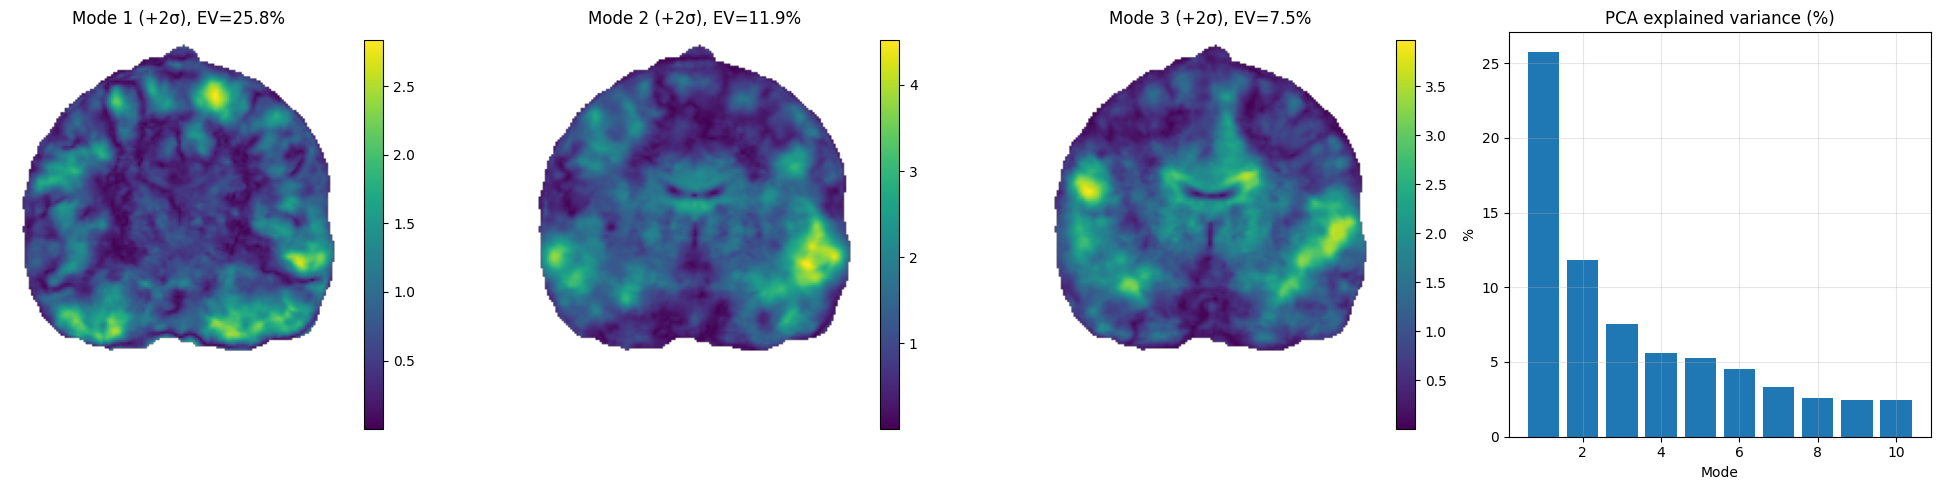

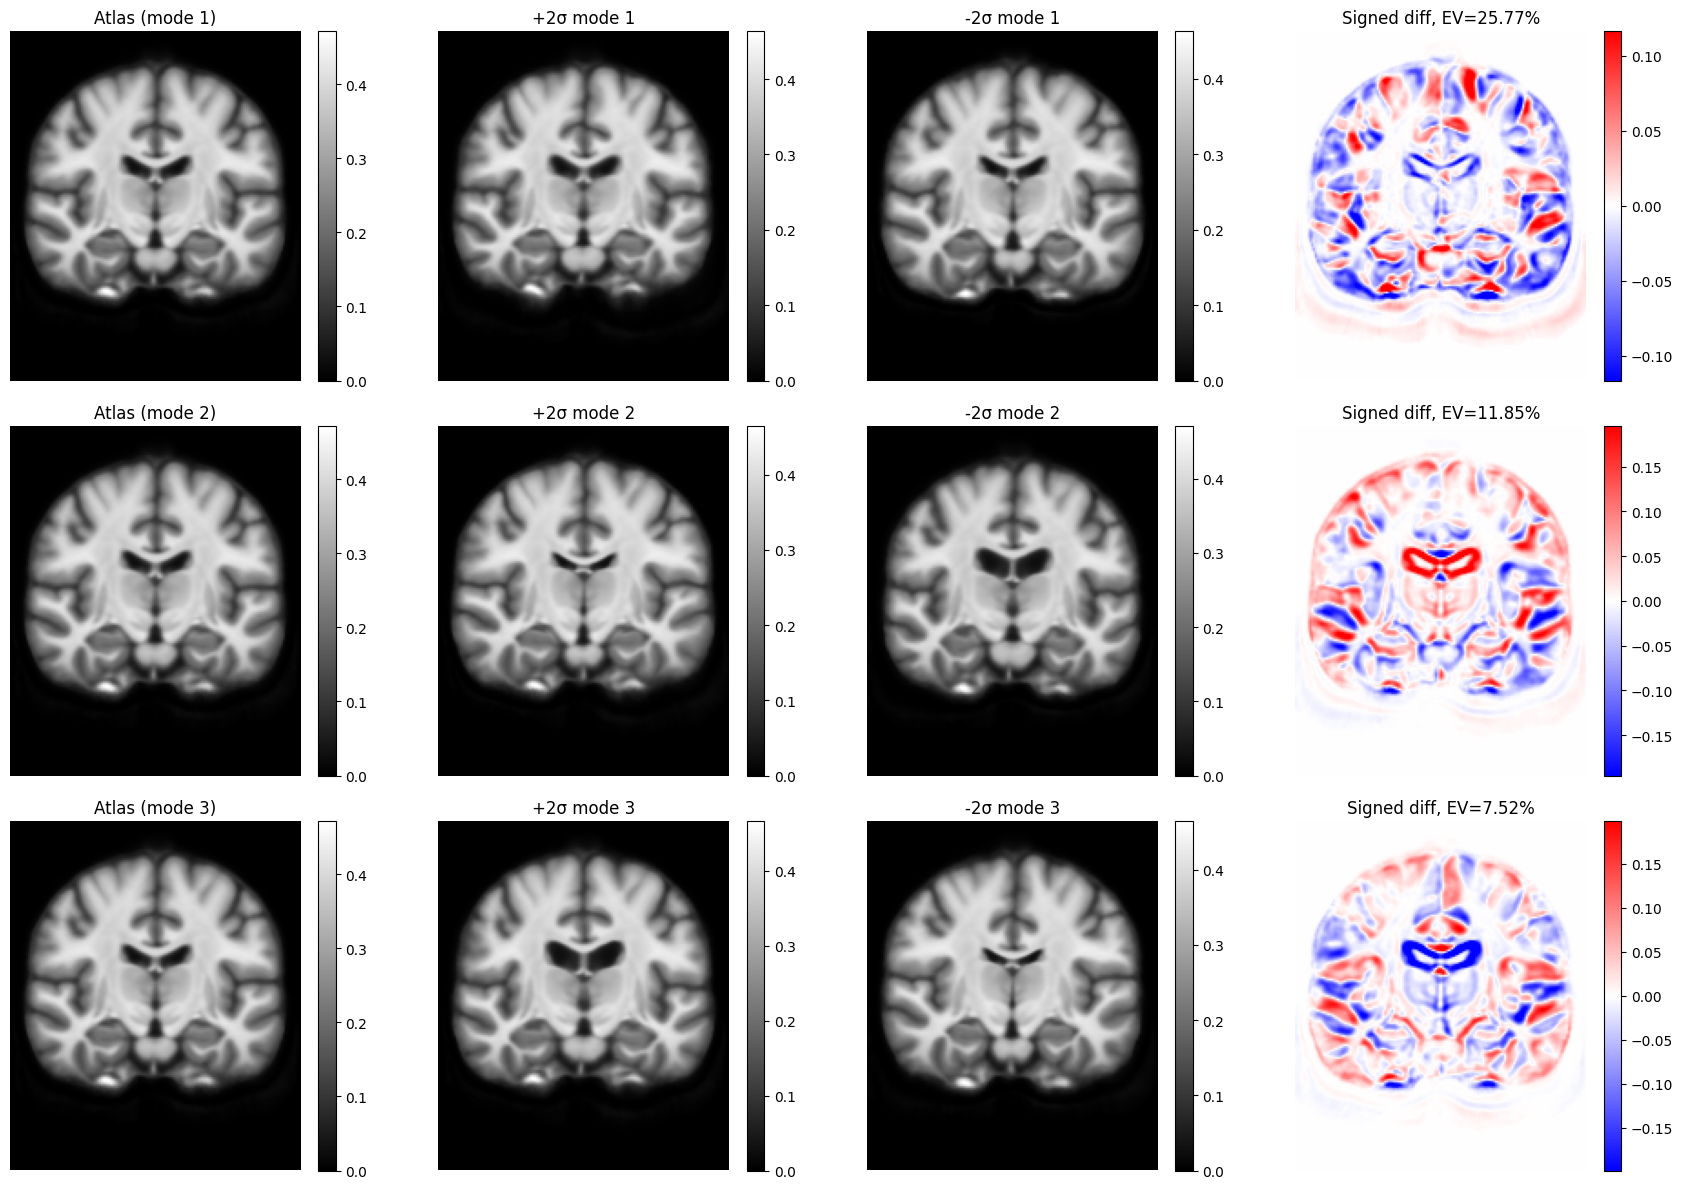

Saved: deformation_outputs


In [38]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---- PCA on deformation fields ----
flow_np = deformation_base['flow_np']
brain_mask = deformation_base['brain_mask']

N, C, H, W = flow_np.shape
X = flow_np.reshape(N, -1)
X_mean = X.mean(axis=0, keepdims=True)
Xc = X - X_mean

_, S, Vt = np.linalg.svd(Xc, full_matrices=False)
explained_var = (S ** 2) / max(N - 1, 1)
explained_ratio = explained_var / np.maximum(explained_var.sum(), 1e-12)

n_modes = int(min(3, Vt.shape[0]))
mean_flow = X_mean.reshape(2, H, W)
mode_maps = []

for m in range(n_modes):
    mode_vec = Vt[m].reshape(2, H, W)
    mode_std = S[m] / np.sqrt(max(N - 1, 1))

    flow_plus = mean_flow + 2.0 * mode_std * mode_vec
    flow_minus = mean_flow - 2.0 * mode_std * mode_vec

    plus_mag = np.sqrt(flow_plus[0] ** 2 + flow_plus[1] ** 2)
    minus_mag = np.sqrt(flow_minus[0] ** 2 + flow_minus[1] ** 2)

    mode_maps.append({
        'mode_id': m + 1,
        'explained_ratio': float(explained_ratio[m]),
        'plus': flow_plus,
        'minus': flow_minus,
        'plus_mag': plus_mag,
        'minus_mag': minus_mag,
    })

print('Explained variance ratio (first modes):')
for m in range(n_modes):
    print(f"  Mode {m+1}: {explained_ratio[m] * 100:.2f}%")
print(f"  Cumulative ({n_modes} modes): {explained_ratio[:n_modes].sum() * 100:.2f}%")

# ---- Simple PCA visual summary ----
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for m in range(3):
    if m < n_modes:
        im = ax[m].imshow(np.where(brain_mask, mode_maps[m]['plus_mag'], np.nan), cmap='viridis')
        ax[m].set_title(f"Mode {m+1} (+2σ), EV={mode_maps[m]['explained_ratio'] * 100:.1f}%")
        ax[m].axis('off')
        plt.colorbar(im, ax=ax[m], fraction=0.046, pad=0.04)
    else:
        ax[m].axis('off')

k_show = min(10, len(explained_ratio))
ax[3].bar(np.arange(1, k_show + 1), explained_ratio[:k_show] * 100)
ax[3].set_title('PCA explained variance (%)')
ax[3].set_xlabel('Mode')
ax[3].set_ylabel('%')
ax[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Atlas interpretation (compact) ----
def _extract_atlas_2d():
    if 'atlas_img' in globals() and np.asarray(atlas_img).ndim == 2:
        return np.asarray(atlas_img, dtype=np.float32)
    if 'atlas' in globals():
        a = atlas.detach().cpu().numpy() if torch.is_tensor(atlas) else np.asarray(atlas)
        while a.ndim > 2:
            a = np.squeeze(a, axis=0)
        return a.astype(np.float32)
    return None


def _resize_to_hw(img2d, out_h, out_w):
    t = torch.from_numpy(img2d).float().unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=(out_h, out_w), mode='bilinear', align_corners=False)
    return t[0, 0].cpu().numpy()


warp_layer_pca = layers.group.Warp2d((H, W))


def _warp_image_with_flow(image_hw, flow_2hw):
    image_t = torch.from_numpy(image_hw).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)  # [1,1,1,H,W]
    flow_t = torch.from_numpy(flow_2hw).float().unsqueeze(0).unsqueeze(0)                 # [1,1,2,H,W]
    with torch.no_grad():
        warped_t = warp_layer_pca(image_t, flow_t)
    return warped_t[0, 0, 0].detach().cpu().numpy()


atlas_2d = _extract_atlas_2d()
if atlas_2d is not None:
    atlas_2d = _resize_to_hw(atlas_2d, H, W)

    fig2, ax2 = plt.subplots(n_modes, 4, figsize=(18, 4 * n_modes))
    if n_modes == 1:
        ax2 = np.expand_dims(ax2, axis=0)

    for m in range(n_modes):
        atlas_plus = _warp_image_with_flow(atlas_2d, mode_maps[m]['plus'])
        atlas_minus = _warp_image_with_flow(atlas_2d, mode_maps[m]['minus'])
        signed_diff = atlas_plus - atlas_minus

        vals = np.abs(signed_diff)[brain_mask]
        thr = np.percentile(vals, 90) if vals.size > 0 else np.inf
        zone_mask = (np.abs(signed_diff) >= thr) & brain_mask if np.isfinite(thr) else np.zeros_like(brain_mask, dtype=bool)

        mode_maps[m]['atlas_plus'] = atlas_plus
        mode_maps[m]['atlas_minus'] = atlas_minus
        mode_maps[m]['signed_diff'] = signed_diff
        mode_maps[m]['zone_mask'] = zone_mask

        lim = max(float(np.percentile(np.abs(signed_diff), 99)), 1e-8)

        im0 = ax2[m, 0].imshow(atlas_2d, cmap='gray')
        ax2[m, 0].set_title(f'Atlas (mode {m+1})')
        ax2[m, 0].axis('off')
        plt.colorbar(im0, ax=ax2[m, 0], fraction=0.046, pad=0.04)

        im1 = ax2[m, 1].imshow(atlas_plus, cmap='gray')
        ax2[m, 1].set_title(f'+2σ mode {m+1}')
        ax2[m, 1].axis('off')
        plt.colorbar(im1, ax=ax2[m, 1], fraction=0.046, pad=0.04)

        im2 = ax2[m, 2].imshow(atlas_minus, cmap='gray')
        ax2[m, 2].set_title(f'-2σ mode {m+1}')
        ax2[m, 2].axis('off')
        plt.colorbar(im2, ax=ax2[m, 2], fraction=0.046, pad=0.04)

        im3 = ax2[m, 3].imshow(signed_diff, cmap='bwr', vmin=-lim, vmax=lim)
        ax2[m, 3].set_title(f'Signed diff, EV={100 * mode_maps[m]["explained_ratio"]:.2f}%')
        ax2[m, 3].axis('off')
        plt.colorbar(im3, ax=ax2[m, 3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
else:
    print('Atlas not found: skipping atlas-based PCA visualization.')

# ---- Final outputs ----
deformation_outputs = {
    **deformation_base,
    'pca_singular_values': S,
    'pca_explained_ratio': explained_ratio,
    'pca_modes': mode_maps,
    'atlas_resized_for_pca': atlas_2d,
    'pca_mode_zone_masks': [m.get('zone_mask', None) for m in mode_maps],
}

print('Saved: deformation_outputs')

**Manifold PGA :**
- Mean = iterative Fréchet/Karcher mean on transformations.
- Tangent vectors = log-map of relative transforms.
- PCA is done in the tangent space at the Fréchet mean.



Using 8/42 fields on cuda
Frechet iter 1/3 | step=1.7016e-01
Frechet iter 2/3 | step=9.8166e-02
Frechet iter 3/3 | step=1.0815e-01


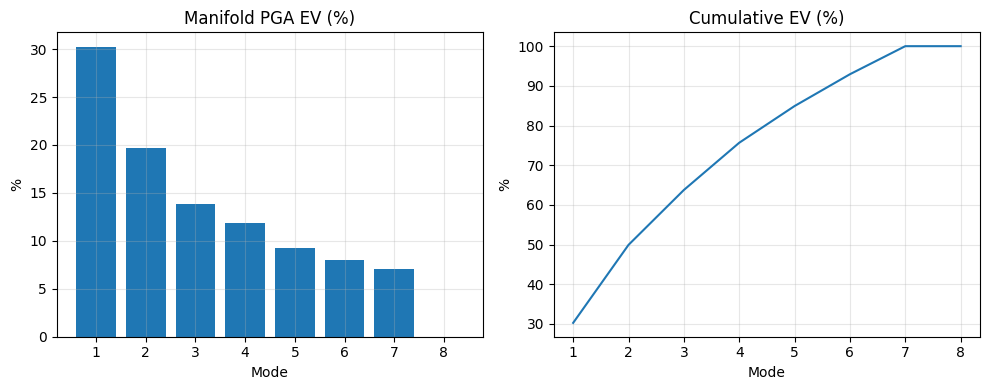

Saved: manifold_pga_outputs


In [ ]:
# Simplified manifold PGA 
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---- small config ----
max_samples = 8
frechet_iters = 3
log_iters = 40
inv_iters = 25
ss_steps = 5
device_m = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


flow_all = np.asarray(flow_np)  


N_all = flow_all.shape[0]
use_idx = np.arange(min(max_samples, N_all))
flows = torch.from_numpy(flow_all[use_idx]).float().to(device_m)
N, C, Hm, Wm = flows.shape
print(f'Using {N}/{N_all} fields on {device_m}')



def _id_grid(B, H, W, device):
    yy, xx = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
    return torch.stack([xx.float(), yy.float()], dim=0).unsqueeze(0).repeat(B, 1, 1, 1)


def _to_norm(abs_grid):
    x = 2.0 * (abs_grid[:, 0] / max(Wm - 1, 1)) - 1.0
    y = 2.0 * (abs_grid[:, 1] / max(Hm - 1, 1)) - 1.0
    return torch.stack([x, y], dim=-1)


def warp_field(field, disp):
    grid_abs = _id_grid(field.shape[0], Hm, Wm, field.device) + disp
    grid = _to_norm(grid_abs)
    return F.grid_sample(field, grid, mode='bilinear', padding_mode='border', align_corners=True)


def compose_disp(u, v):
    return v + warp_field(u, v)


def invert_disp(u, n_iter=20):
    inv = -u.clone()
    for _ in range(n_iter):
        inv = -warp_field(u, inv)
    return inv


def exp_svf(v, n_steps=5):
    u = v / (2 ** n_steps)
    for _ in range(n_steps):
        u = compose_disp(u, u)
    return u


def smooth_penalty(v):
    dx = v[:, :, :, 1:] - v[:, :, :, :-1]
    dy = v[:, :, 1:, :] - v[:, :, :-1, :]
    return dx.pow(2).mean() + dy.pow(2).mean()


def log_map(phi, n_iter=40, lr=0.06, lam=1e-4):
    target = phi.detach()
    v = target.clone().requires_grad_(True)
    opt = torch.optim.Adam([v], lr=lr)
    for _ in range(n_iter):
        opt.zero_grad()
        loss = ((exp_svf(v, n_steps=ss_steps) - target) ** 2).mean() + lam * smooth_penalty(v)
        loss.backward()
        opt.step()
    return v.detach()

# ---- Frechet mean ----
mu = flows.mean(dim=0, keepdim=True)
for it in range(frechet_iters):
    mu_inv = invert_disp(mu, n_iter=inv_iters)
    xi_list = []
    for i in range(N):
        rel = compose_disp(mu_inv, flows[i:i+1])
        xi_list.append(log_map(rel, n_iter=log_iters))
    Xi_it = torch.cat(xi_list, dim=0)
    delta = Xi_it.mean(dim=0, keepdim=True)
    mu = compose_disp(mu, exp_svf(delta, n_steps=ss_steps))
    print(f'Frechet iter {it+1}/{frechet_iters} | step={(delta.pow(2).mean().sqrt().item()):.4e}')

# ---- tangent vectors at mu + PCA ----
mu_inv = invert_disp(mu, n_iter=inv_iters)
Xi = []
for i in range(N):
    rel = compose_disp(mu_inv, flows[i:i+1])
    Xi.append(log_map(rel, n_iter=log_iters))
Xi = torch.cat(Xi, dim=0)

X = Xi.reshape(N, -1).detach().cpu().numpy()
Xc = X - X.mean(axis=0, keepdims=True)
U_m, S_m, Vt_m = np.linalg.svd(Xc, full_matrices=False)
ev = (S_m ** 2) / max(N - 1, 1)
ev_ratio = ev / np.maximum(ev.sum(), 1e-12)
cum_ev = np.cumsum(ev_ratio)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(np.arange(1, min(8, len(ev_ratio))+1), 100*ev_ratio[:min(8, len(ev_ratio))])
plt.title('Manifold PGA EV (%)')
plt.xlabel('Mode')
plt.ylabel('%')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(np.arange(1, len(cum_ev)+1), 100*cum_ev)
plt.title('Cumulative EV (%)')
plt.xlabel('Mode')
plt.ylabel('%')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

manifold_pga_outputs = {
    'indices_used': use_idx,
    'frechet_mean_disp': mu.detach().cpu().numpy(),
    'tangent_vectors': Xi.detach().cpu().numpy(),
    'U': U_m,
    'S': S_m,
    'Vt': Vt_m,
    'explained_var': ev,
    'explained_ratio': ev_ratio,
    'cum_explained': cum_ev,
}

print('Saved: manifold_pga_outputs')

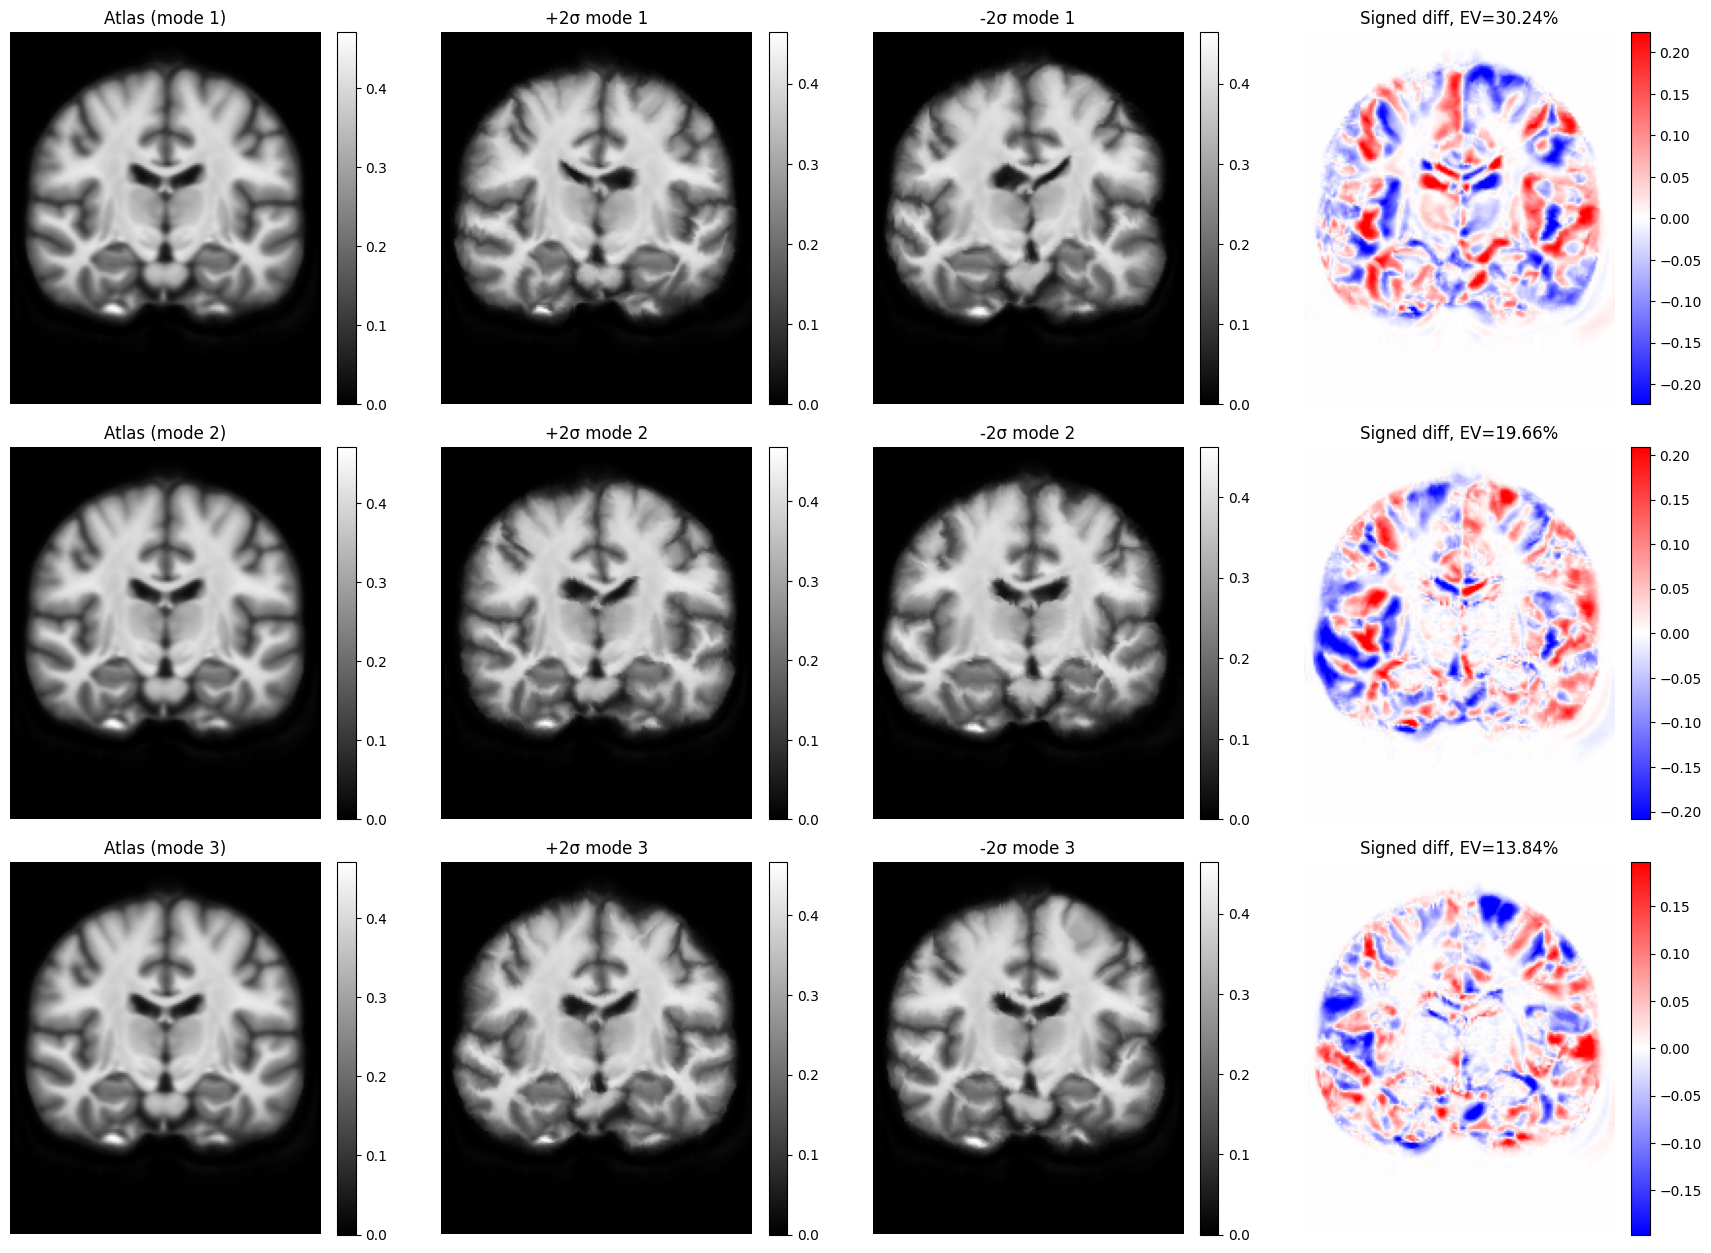

Saved: manifold_anatomical_outputs


In [34]:
# Simplified anatomical reconstructions from manifold modes
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

if 'manifold_pga_outputs' not in globals():
    raise RuntimeError('Run previous manifold PGA cell first.')

mu = torch.from_numpy(manifold_pga_outputs['frechet_mean_disp']).float()
Vt_m = manifold_pga_outputs['Vt']
S_m = manifold_pga_outputs['S']
ev_ratio = manifold_pga_outputs['explained_ratio']

_, _, Hm, Wm = mu.shape
mode_stds = S_m / np.sqrt(max(Vt_m.shape[0], 1))

# atlas base
if 'atlas_img' in globals() and np.asarray(atlas_img).ndim == 2:
    atlas_base = np.asarray(atlas_img, dtype=np.float32)
else:
    atlas_base = atlas.detach().cpu().numpy() if torch.is_tensor(atlas) else np.asarray(atlas)
    while atlas_base.ndim > 2:
        atlas_base = np.squeeze(atlas_base, axis=0)
    atlas_base = atlas_base.astype(np.float32)

atlas_t = torch.from_numpy(atlas_base).float().unsqueeze(0).unsqueeze(0)
atlas_t = F.interpolate(atlas_t, size=(Hm, Wm), mode='bilinear', align_corners=False)
atlas_base = atlas_t[0, 0].cpu().numpy()


def warp_image_with_disp(img_hw, disp_2hw):
    img = torch.from_numpy(img_hw).float().unsqueeze(0).unsqueeze(0)
    disp = torch.from_numpy(disp_2hw).float().unsqueeze(0)
    yy, xx = torch.meshgrid(torch.arange(Hm), torch.arange(Wm), indexing='ij')
    x_new = xx.float() + disp[0, 0]
    y_new = yy.float() + disp[0, 1]
    x_norm = 2.0 * (x_new / max(Wm - 1, 1)) - 1.0
    y_norm = 2.0 * (y_new / max(Hm - 1, 1)) - 1.0
    grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(0)
    warped = F.grid_sample(img, grid, mode='bilinear', padding_mode='border', align_corners=True)
    return warped[0, 0].detach().cpu().numpy()

n_modes_show = int(min(3, Vt_m.shape[0]))
alpha = 2.0

fig, ax = plt.subplots(n_modes_show, 4, figsize=(18, 4.2 * n_modes_show))
if n_modes_show == 1:
    ax = np.expand_dims(ax, axis=0)

manifold_anatomical_outputs = []
for k in range(n_modes_show):
    e_k = Vt_m[k].reshape(2, Hm, Wm).astype(np.float32)
    sigma = float(mode_stds[k])

    v_plus = torch.from_numpy(alpha * sigma * e_k).unsqueeze(0)
    v_minus = -v_plus

    phi_plus = compose_disp(mu, exp_svf(v_plus, n_steps=5))
    phi_minus = compose_disp(mu, exp_svf(v_minus, n_steps=5))

    disp_plus = phi_plus[0].detach().cpu().numpy()
    disp_minus = phi_minus[0].detach().cpu().numpy()

    atlas_plus = warp_image_with_disp(atlas_base, disp_plus)
    atlas_minus = warp_image_with_disp(atlas_base, disp_minus)
    signed_diff = atlas_plus - atlas_minus

    lim = max(float(np.percentile(np.abs(signed_diff), 99)), 1e-8)

    im0 = ax[k, 0].imshow(atlas_base, cmap='gray')
    ax[k, 0].set_title(f'Atlas (mode {k+1})')
    ax[k, 0].axis('off')
    plt.colorbar(im0, ax=ax[k, 0], fraction=0.046, pad=0.04)

    im1 = ax[k, 1].imshow(atlas_plus, cmap='gray')
    ax[k, 1].set_title(f'+2σ mode {k+1}')
    ax[k, 1].axis('off')
    plt.colorbar(im1, ax=ax[k, 1], fraction=0.046, pad=0.04)

    im2 = ax[k, 2].imshow(atlas_minus, cmap='gray')
    ax[k, 2].set_title(f'-2σ mode {k+1}')
    ax[k, 2].axis('off')
    plt.colorbar(im2, ax=ax[k, 2], fraction=0.046, pad=0.04)

    im3 = ax[k, 3].imshow(signed_diff, cmap='bwr', vmin=-lim, vmax=lim)
    ax[k, 3].set_title(f'Signed diff, EV={100*ev_ratio[k]:.2f}%')
    ax[k, 3].axis('off')
    plt.colorbar(im3, ax=ax[k, 3], fraction=0.046, pad=0.04)

    manifold_anatomical_outputs.append({
        'mode_id': k + 1,
        'explained_ratio': float(ev_ratio[k]),
        'atlas_plus': atlas_plus,
        'atlas_minus': atlas_minus,
        'signed_diff': signed_diff,
    })

plt.tight_layout()
plt.show()

manifold_anatomical_outputs = {
    'atlas_reference': atlas_base,
    'alpha_sigma': alpha,
    'mode_reconstructions': manifold_anatomical_outputs,
}
print('Saved: manifold_anatomical_outputs')